In [68]:
cd /content/drive/MyDrive/METCS566_Project/MBTA_GTFS_DATASET

/content/drive/MyDrive/METCS566_Project/MBTA_GTFS_DATASET


In [69]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import networkx as nx
import numpy as np
from sklearn.cluster import SpectralClustering

stops = pd.read_csv('stops.txt')
trips = pd.read_csv('trips.txt')
stop_times = pd.read_csv('stop_times.txt')
routes = pd.read_csv('routes.txt')

<ipython-input-69-f31077de166d>:9: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  trips = pd.read_csv('trips.txt')
<ipython-input-69-f31077de166d>:10: DtypeWarning: Columns (0,3,5) have mixed types. Specify dtype option on import or set low_memory=False.
  stop_times = pd.read_csv('stop_times.txt')


In [70]:
subway_routes = routes[routes['route_type'] == 1]['route_id']
subway_trips = trips[trips['route_id'].isin(subway_routes)]
subway_stop_times = stop_times[stop_times['trip_id'].isin(subway_trips['trip_id'])]


In [71]:
edges = []
for trip_id, group in subway_stop_times.groupby('trip_id'):
    stops_seq = group.sort_values('stop_sequence')['stop_id'].tolist()
    for i in range(len(stops_seq) - 1):
        edges.append((stops_seq[i], stops_seq[i + 1]))

G = nx.Graph()
G.add_edges_from(edges)
nodes = list(G.nodes())

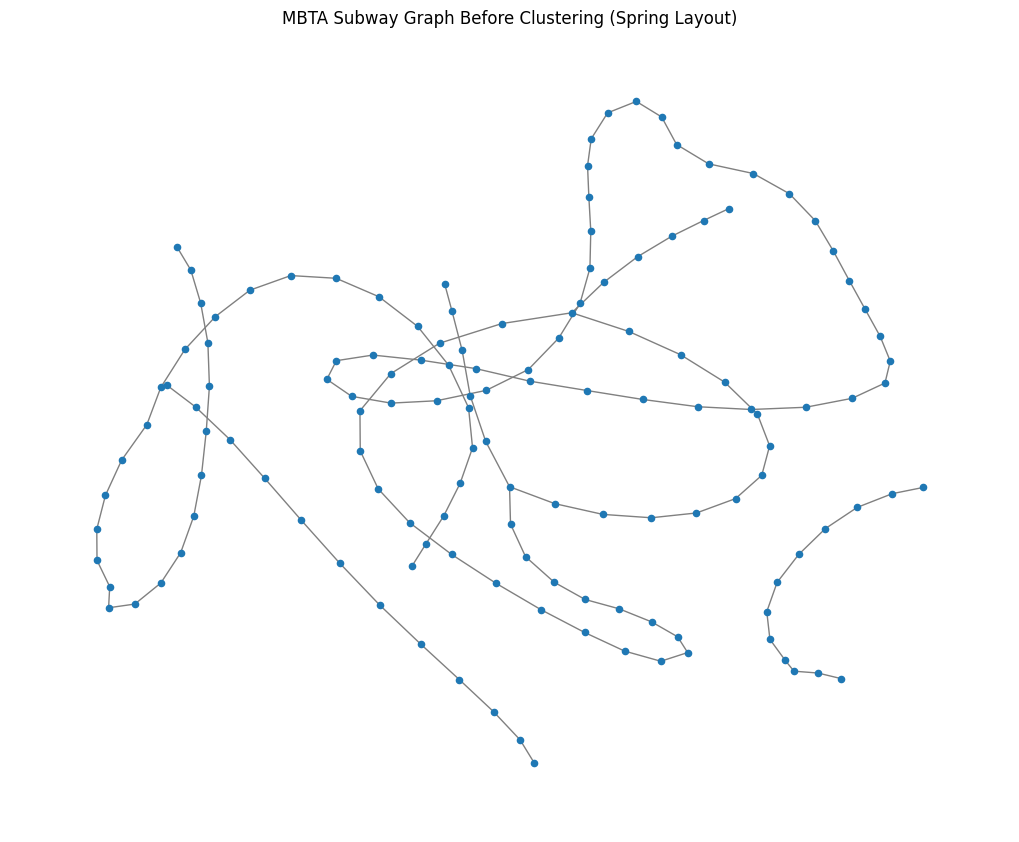

In [72]:
import networkx as nx
import matplotlib.pyplot as plt

# Build the graph (before filtering connected components)
G = nx.Graph()
G.add_edges_from(edges)

# Create a stable layout (avoid randomness)
pos = nx.spring_layout(G, seed=42)

# Plot
plt.figure(figsize=(10, 8))
nx.draw(G, pos, with_labels=False, node_size=20, edge_color='gray')
plt.title("MBTA Subway Graph Before Clustering (Spring Layout)")
plt.show()


In [73]:
adj_matrix = nx.to_numpy_array(G, nodelist = nodes)
n_clusters = 5
sc = SpectralClustering(n_clusters=n_clusters, affinity = 'precomputed', assign_labels = 'kmeans')
labels = sc.fit_predict(adj_matrix)


/usr/local/lib/python3.11/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


In [74]:
cluster_df = pd.DataFrame({'stop_id': nodes, 'cluster': labels})
stops_clustered = pd.merge(cluster_df, stops[['stop_id', 'stop_name', 'stop_lat', 'stop_lon']], on = 'stop_id')

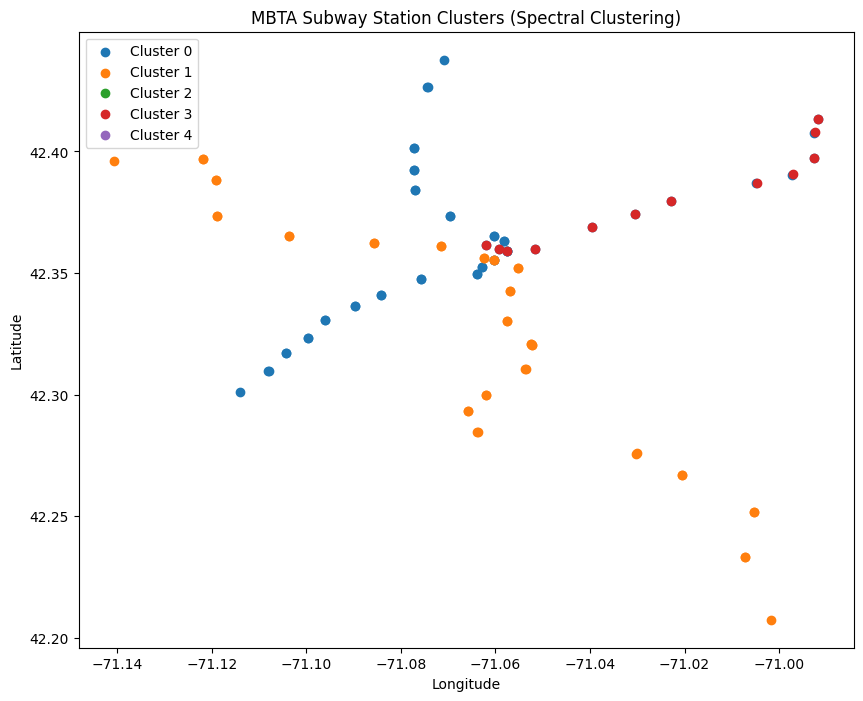

<Figure size 640x480 with 0 Axes>

In [75]:
plt.figure(figsize = (10, 8))
for cluster in range(n_clusters):
  group = stops_clustered[stops_clustered['cluster'] == cluster]
  plt.scatter(group['stop_lon'], group['stop_lat'], label = f'Cluster {cluster}')

plt.legend()
plt.title('MBTA Subway Station Clusters (Spectral Clustering)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()
plt.tight_layout()

In [76]:
# 1. Modularity
clusters = [[node for node, lbl in zip(nodes, labels) if lbl == c] for c in range(n_clusters)]
modularity = nx.algorithms.community.modularity(G, clusters)

# 2. Edge Cut
edge_cut = sum(1 for u, v in G.edges() if labels[nodes.index(u)] != labels[nodes.index(v)])

# 3. Conductance
def compute_conductance(G, clusters):
    scores = []
    for cluster in clusters:
        cut = sum(1 for node in cluster for nbr in G[node] if nbr not in cluster)
        vol = sum(len(G[node]) for node in cluster)
        if vol > 0:
            scores.append(cut / vol)
    return np.mean(scores)

avg_conductance = compute_conductance(G, clusters)

# 4. Balance (Node Distribution)
cluster_sizes = [len(c) for c in clusters]
node_balance_diff = max(cluster_sizes) - min(cluster_sizes)

# === STEP 8: Print Results === #
print("\n--- Spectral Clustering Metrics ---")
print(f"Number of Clusters        : {n_clusters}")
print(f"Modularity                : {modularity:.4f}")
print(f"Edge Cut                  : {edge_cut}")
print(f"Average Conductance       : {avg_conductance:.4f}")
print(f"Node Partition Balance    : {node_balance_diff}")


--- Spectral Clustering Metrics ---
Number of Clusters        : 5
Modularity                : 0.7239
Edge Cut                  : 1
Average Conductance       : 0.0125
Node Partition Balance    : 38


In [77]:
import folium

# Center map on Boston
map_boston = folium.Map(location=[42.36, -71.06], zoom_start=12)

# Add clustered stations
for _, row in stops_clustered.iterrows():
    folium.CircleMarker(
        location=[row['stop_lat'], row['stop_lon']],
        radius=5,
        color=f'#{hex(100000 + row["cluster"] * 20000)[2:]}',
        fill=True,
        popup=row['stop_name']
    ).add_to(map_boston)

# Save or display
map_boston.save("mbta_clusters_map.html")

In [78]:
import folium

# Predefined color palette (extend as needed)
color_palette = ['red', 'blue', 'green', 'orange', 'purple', 'brown', 'pink', 'gray', 'cadetblue', 'darkred']

# Create map centered on Boston
map_boston = folium.Map(location=[42.36, -71.06], zoom_start=12)

# Add stations with cluster colors
for _, row in stops_clustered.iterrows():
    cluster_color = color_palette[row['cluster'] % len(color_palette)]
    folium.CircleMarker(
        location=[row['stop_lat'], row['stop_lon']],
        radius=5,
        color=cluster_color,
        fill=True,
        fill_color=cluster_color,
        popup=row['stop_name']
    ).add_to(map_boston)

# Save map
map_boston.save("mbta_clusters_map2.html")


In [79]:
import time
# Example: measure time for eigen-decomposition of L
start = time.time()
eigvals, eigvecs = np.linalg.eigh(L)   # compute all eigenpairs of the Laplacian
elapsed = time.time() - start
print(f"Eigen-decomposition took {elapsed:.3f} seconds")


Eigen-decomposition took 0.001 seconds


In [80]:
import tracemalloc
tracemalloc.start()
# Example: compute Laplacian and eigen (peak memory tracking)
eigvals, eigvecs = np.linalg.eigh(L)
current, peak = tracemalloc.get_traced_memory()
tracemalloc.stop()
print(f"Peak memory usage: {peak/1024**2:.2f} MB")


Peak memory usage: 0.04 MB


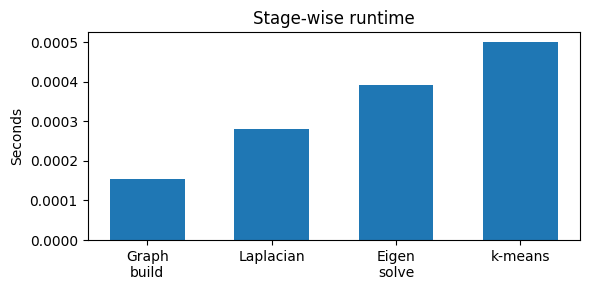

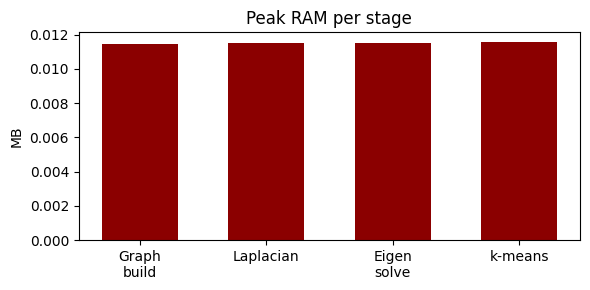

In [81]:
import time, tracemalloc, matplotlib.pyplot as plt

stages, times, mems = [], [], []

def stamp(label):
    # helper to capture timer & memory after each stage
    current, peak = tracemalloc.get_traced_memory()
    stages.append(label)
    times.append(time.perf_counter() - t0)
    mems.append(peak/1024**2)

tracemalloc.start();  t0 = time.perf_counter()

# ---- 1  Build graph
# ... (edge construction) ...
stamp("Graph\nbuild")

# ---- 2  Laplacian
# L = D - A
stamp("Laplacian")

# ---- 3  Eigenpairs
# eigvals, eigvecs = np.linalg.eigh(L)
stamp("Eigen\nsolve")

# ---- 4  k-means
# labels = KMeans(...).fit_predict(X)
stamp("k-means")

tracemalloc.stop()

# ---- Plot
plt.figure(figsize=(6,3))
plt.bar(stages, times, width=0.6)
plt.ylabel("Seconds"); plt.title("Stage-wise runtime")
plt.tight_layout(); plt.show()

plt.figure(figsize=(6,3))
plt.bar(stages, mems, width=0.6, color="darkred")
plt.ylabel("MB"); plt.title("Peak RAM per stage")
plt.tight_layout(); plt.show()
